# Chromatin PTR analysis
February 32, 2024

Update PTR analysis of latest chromatin deconvolution results. Higher resolution chromatin results. Goal is to summarize a gene's cycling chromatin with a top k values of cycling chromatin.

Possibly sweep for what k values can be reasonable. Maybe think through how we can sweep for an appropriate k.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [25]:
import glob

outdir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


In [26]:
from src.timer import Timer

timer = Timer()

peak_to_trough_analysis.load_ptr_files()
peak_to_trough_analysis.sort_gene_ptrs()
peak_to_trough_analysis.compute_gene_ptr_rank_per_k()

timer.get_time()

'00:00:13.13'

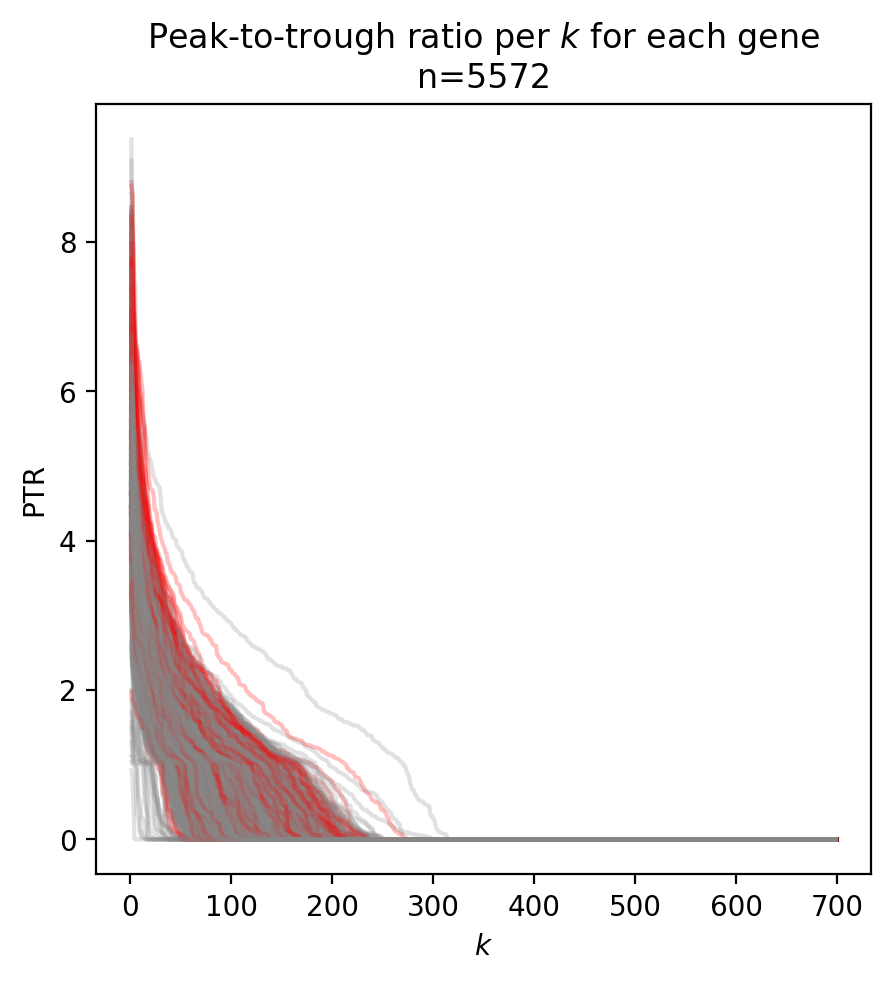

In [27]:
peak_to_trough_analysis.plot_ptr_k_gene()

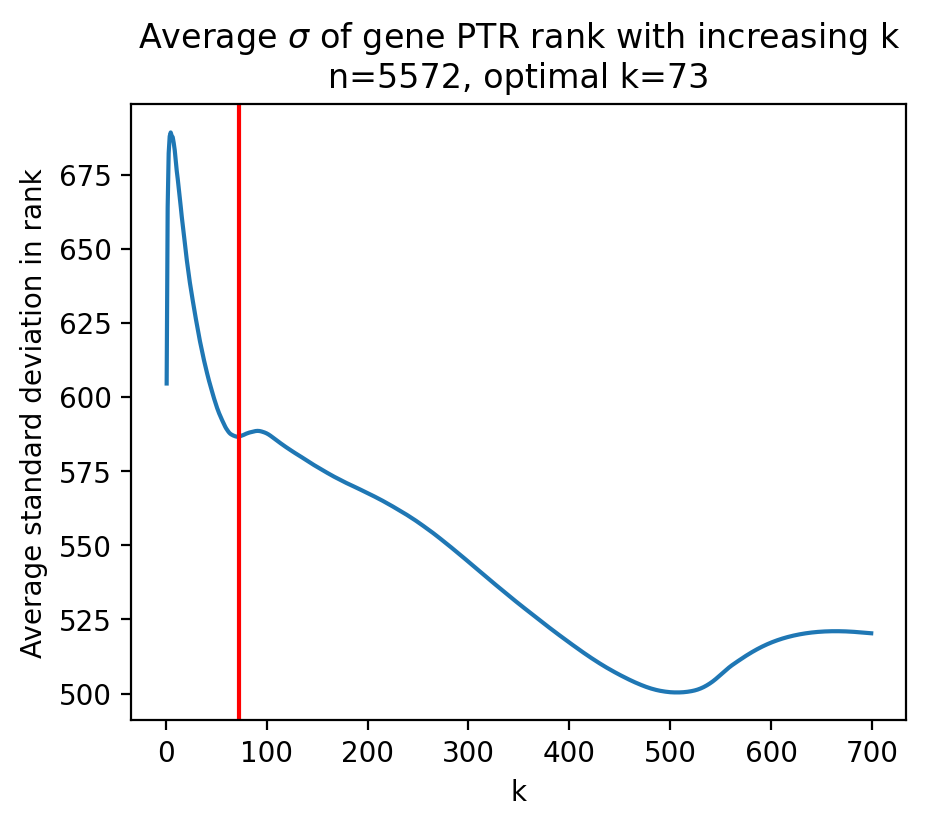

In [47]:
peak_to_trough_analysis.compute_optimal_k()

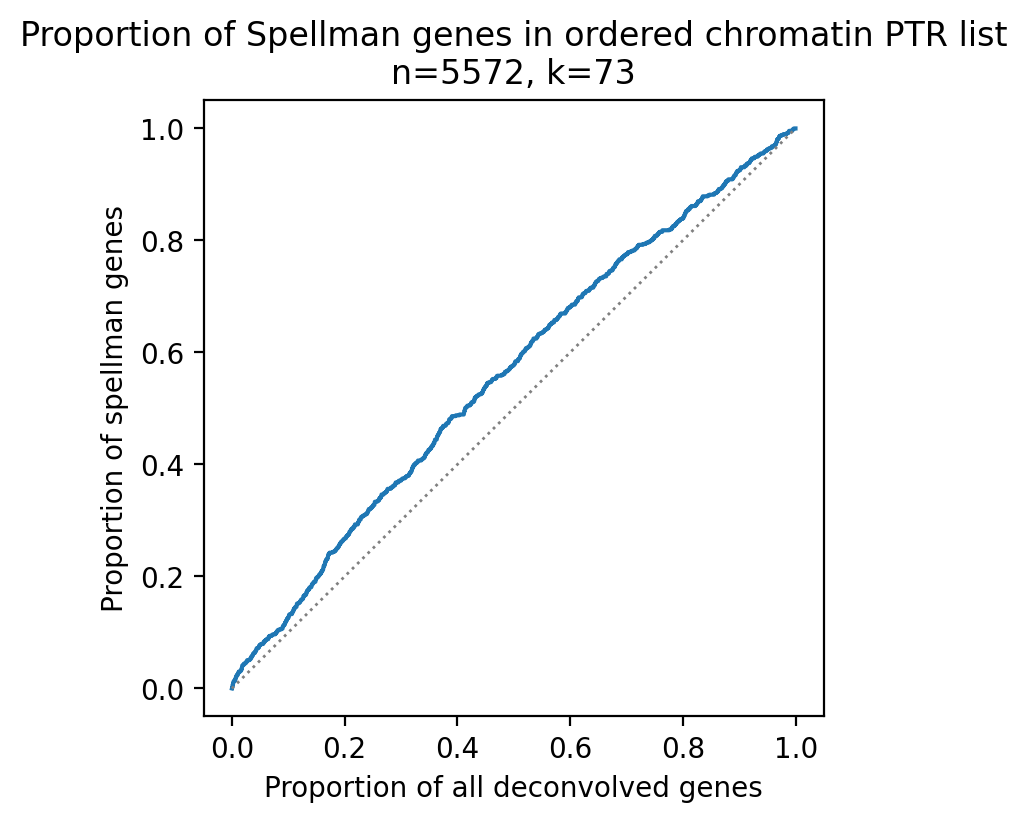

In [48]:
peak_to_trough_analysis.spellman_analysis()

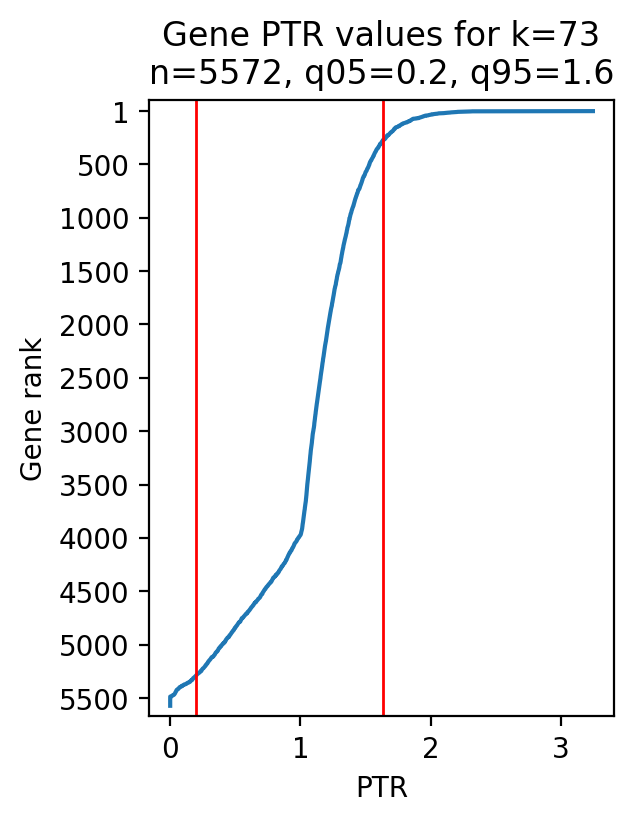

In [49]:
peak_to_trough_analysis.plot_ptrs_per_gene()

## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [52]:
k_selected_ptr = peak_to_trough_analysis.k_sorted_genes['ptr']

In [32]:
mean = peak_to_trough_analysis.summarize_ptrs(np.mean)
median = peak_to_trough_analysis.summarize_ptrs(np.median)
q95 = peak_to_trough_analysis.compute_q_vals(0.95)

In [82]:
# What if we were to try the other idea in which we use the threshold as a metric
# what proportion of the chromatin window meets the threshold criteria?

from src.ptr_analysis_plotter import threshold_img

L=1e-3
H=2

# Let's choose two genes and see how they look with different threshold cutoffs
# Cell cycling and non-cell cycling genes


peak_to_trough_analysis.ptrs_df


,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
orf_name,,,,,,,,,,,,,,,,,,,,,
YAL068C,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
YAL067W-A,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
YAL067C,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
YAL065C,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,...,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011,0.000011
YAL064W-B,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,...,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001,0.00001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR196W,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
YPR198W,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012
YPR199C,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,...,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012,0.000012


In [134]:

def plot_threshold_scan(peak_to_trough_analysis, gene_name):
    geneset = peak_to_trough_analysis.geneset
    gene = geneset[geneset.gene == gene_name].iloc[0]
    orf_name = gene.name
    gene_ptr = peak_to_trough_analysis.ptrs_df.loc[orf_name]
    gene_ptr_img = gene_ptr.values.reshape(peak_to_trough_analysis.image_shape).astype(float)

    hs = np.linspace(1, 5, 4)
    ls = np.linspace(1e-3, 1, 4)
    num_h = len(hs)
    num_l = len(ls)

    plt.figure(figsize=(1.8, 0.75))
    plt.imshow(gene_ptr_img, cmap='Blues', origin='lower', aspect='auto')
    plt.xticks([])
    plt.yticks([])
            
    if gene.strand == '-':
        plt.xlim(plt.xlim()[1], plt.xlim()[0])

    fig, axs = plt.subplots(num_h, num_l, figsize=(8, 3))

    for i in range(num_h):
        for j in range(num_l):
            ax = axs[i][j]
            low = ls[j]
            hi = hs[i]

            thresholded_ptr = threshold_img(gene_ptr_img, L=low, H=hi)
            ax.imshow(thresholded_ptr, cmap='Blues', origin='lower', aspect='auto')
            ax.set_xticks([])
            ax.set_yticks([])
            
            if gene.strand == '-':
                ax.set_xlim(ax.get_xlim()[1], ax.get_xlim()[0])


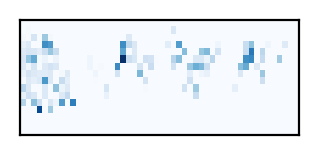

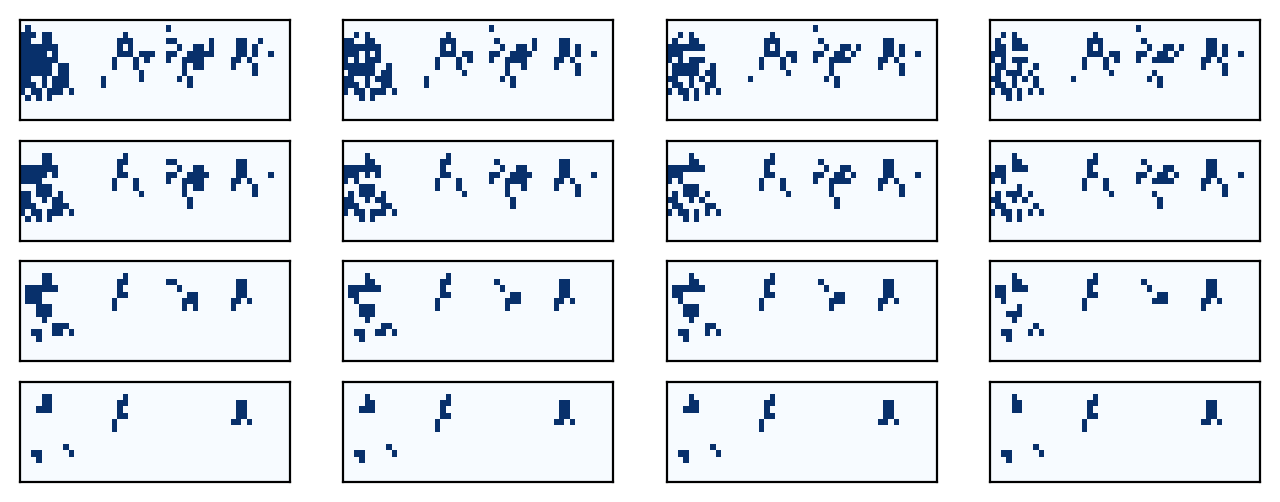

In [135]:
plot_threshold_scan(peak_to_trough_analysis, 'CLB2')

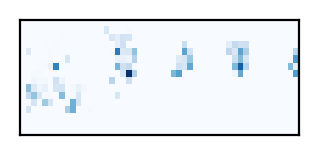

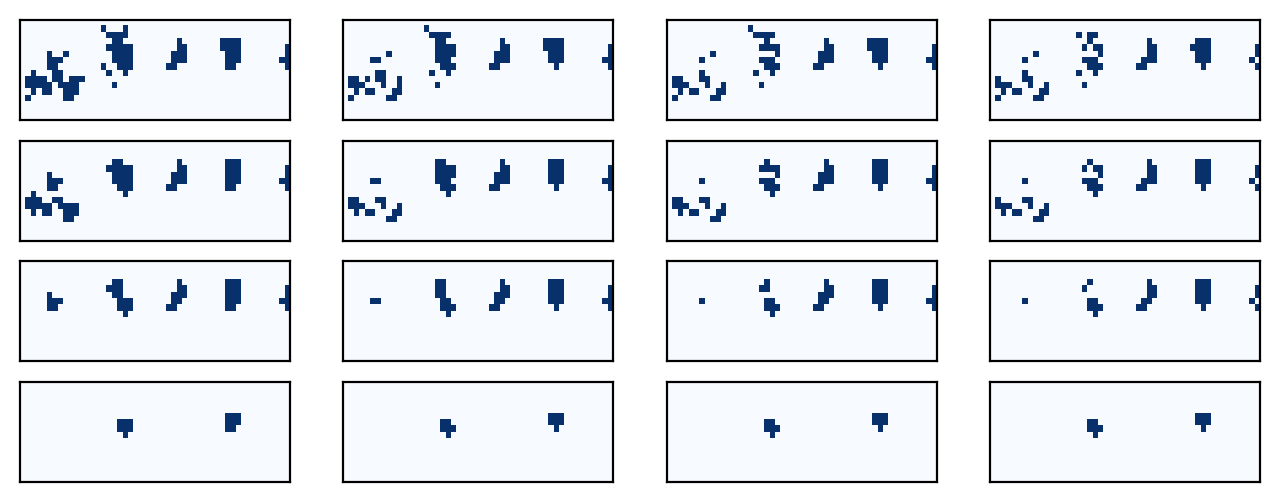

In [136]:
plot_threshold_scan(peak_to_trough_analysis, 'SSK22')

In [154]:
from src.ptr_analysis_plotter import PTRAnalysisPlotter

plotter = PTRAnalysisPlotter(peak_to_trough_analysis, ptr_entropy)


In [158]:
plotter.set_quantiles(list(reversed([0.0, 0.01, 0.05, 0.2, 0.3, 0.4, 0.5,
                       0.95, 0.99, 0.995, 1.0])))


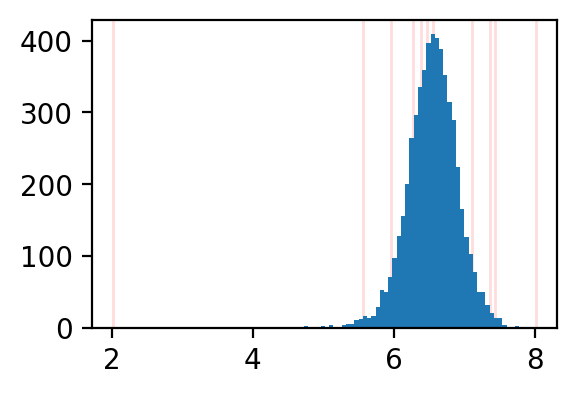

In [159]:
plotter.plot_distribution()

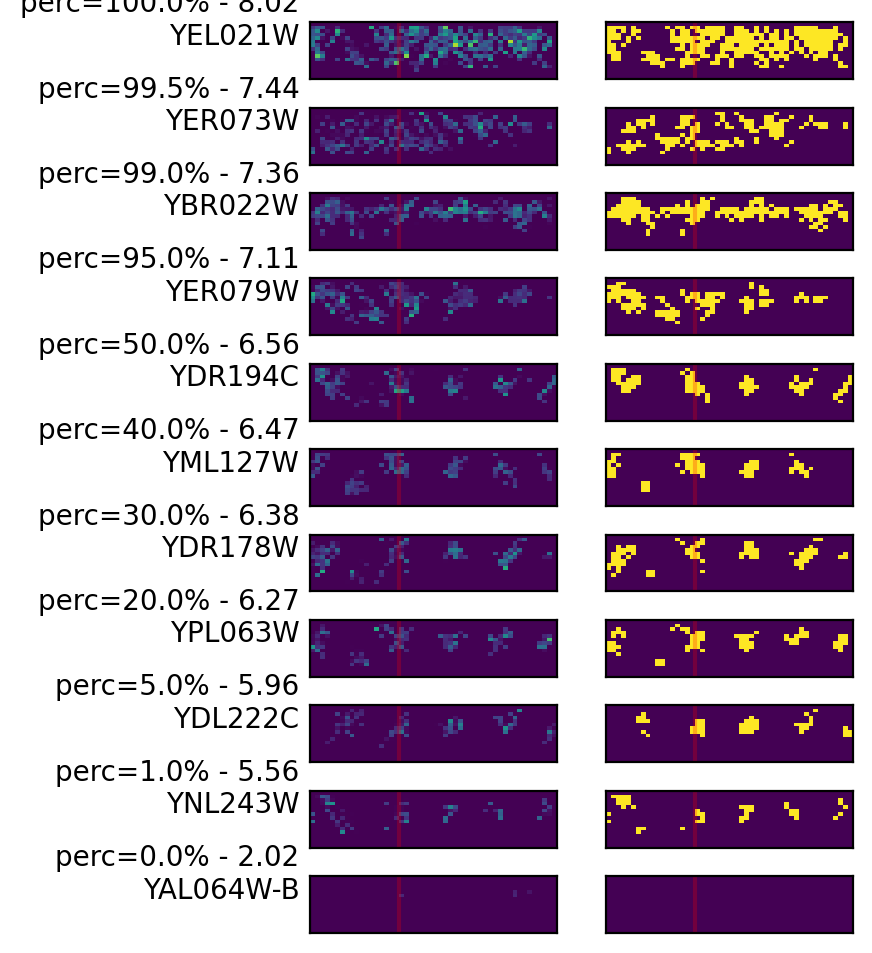

In [160]:
plotter.plot_metric_examples_quantiles()


In [145]:
from scipy.stats import entropy

def calc_entropy(cross_cor, base=2):
    # compute estimated probability distribution
    total_cc = np.sum(cross_cor)
    prob_est = 1.* cross_cor / (total_cc+0.01) # avoid divide by 0
    return entropy(prob_est, base=base)

calc_entropy(gene_ptr.values.astype(float))


6.629105642540008

In [152]:
ptrs_df = peak_to_trough_analysis.ptrs_df.astype(float)
ptr_entropy = ptrs_df.apply(calc_entropy, axis=1)


In [161]:
ptr_entropy.sort_values()

orf_name
YAL064W-B    2.024910
YLR460C      3.258306
YCR102C      3.359281
YFL062W      3.684131
YHL048W      4.090835
               ...   
YDL184C      7.617691
YOL019W      7.699511
YLR110C      7.757084
YOL086C      7.775326
YEL021W      8.017057
Length: 5572, dtype: float64

In [162]:
# What about change in entropy for each gene?

In [182]:
from cc_src.chromatin_model import load_chromatin_model_from_disk

chromatin_dir = 'output/deconvolve_rep1_g006_2024_02_20/chromatin/'


In [194]:
def calculate_entropy(gene_name, chromatin_dir):
    chromatin_model = load_chromatin_model_from_disk(gene_name, chromatin_dir)
    f = chromatin_model.deconvolved_f()
    f = f.reshape((f.shape[0], -1))
    f_entropies = np.apply_along_axis(calc_entropy, 1, f)
    
    CG1_indices = chromatin_model.config.get_Hpositions_for_phase("CG1")
    DG1_indices = chromatin_model.config.get_Hpositions_for_phase("DG1")
    postG1_indices = chromatin_model.config.get_Hpositions_for_phase("postG1")
    
    indices = np.concatenate([CG1_indices, postG1_indices, DG1_indices, postG1_indices])
    plt.plot(f_entropies[indices])
    
    plt.axvline(len(CG1_indices))
    plt.axvline(len(CG1_indices)+len(postG1_indices))
    plt.axvline(len(CG1_indices)+len(postG1_indices)+len(DG1_indices))
    plt.axvline(len(CG1_indices)+len(postG1_indices)+len(DG1_indices))
    
    plt.ylim(5, 7)

Loading MNase reads for YPR119W/CLB2...Loading chromosome reads: 16
Done.


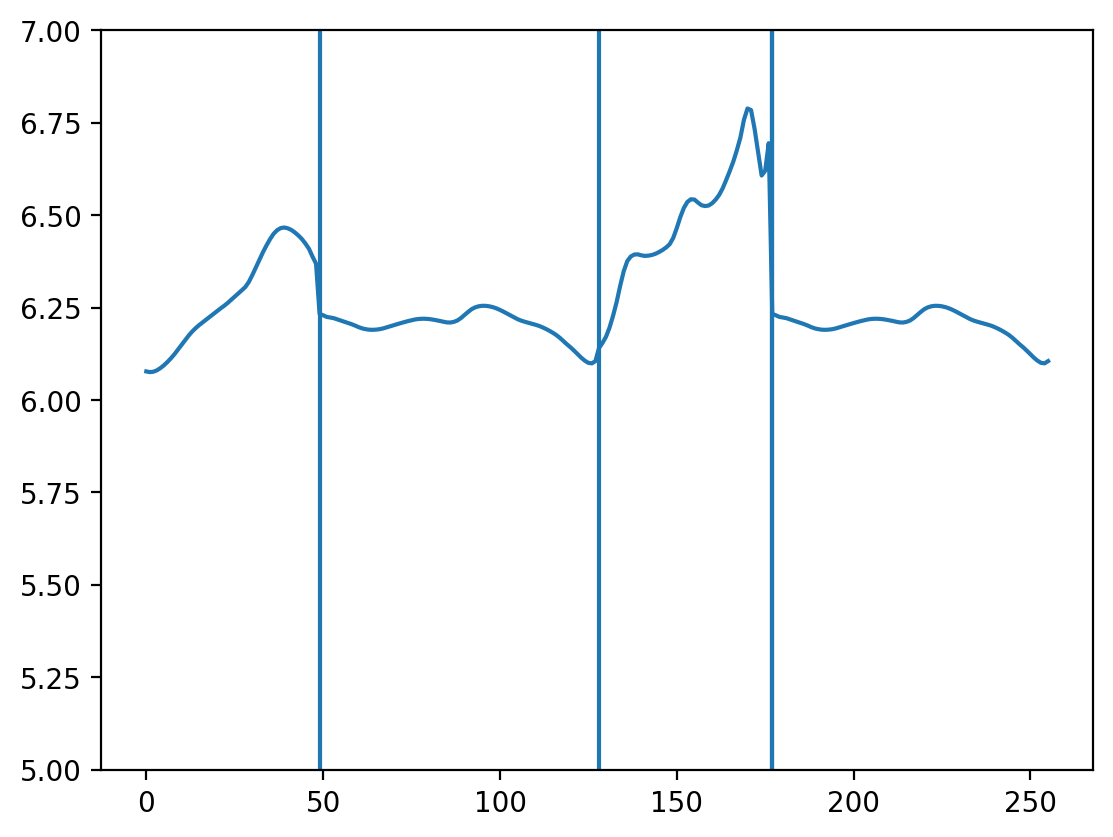

In [195]:
calculate_entropy("CLB2", chromatin_dir)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.


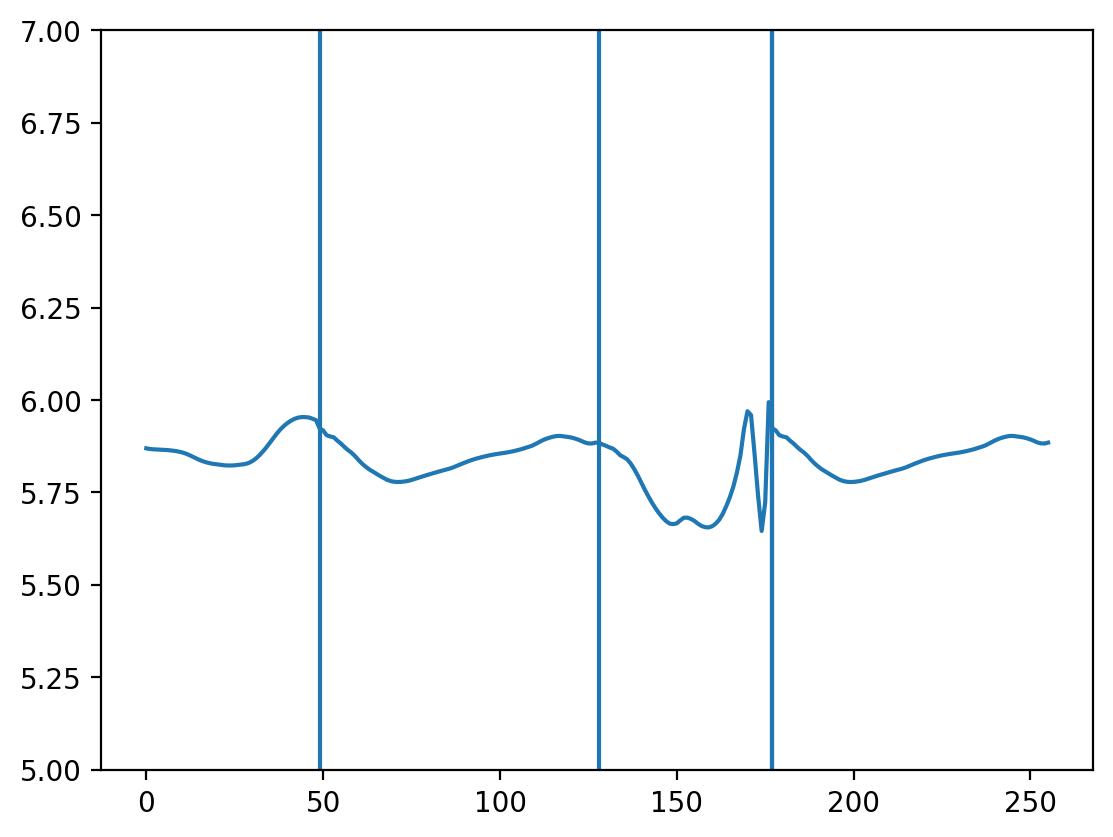

In [196]:
calculate_entropy("SSK22", chromatin_dir)